# Galaxy Scaling Relations

This tutorial notebook will walk you through how to plot simple scaling relations for galaxies using column queries in opencosmo. 

- Tully Fisher relation
- Faber-Jackson relation
- Star Formation Rate
- Quenched Fraction


<div class="meta-block">
  <div class="meta-row">
    <span class="meta-label">Data</span>
    <span class="chip chip-data">Galaxy Properties</span>
  </div>

  <div class="meta-row">
    <span class="meta-label">Tasks</span>
    <span class="chip chip-task">Query</span>
    <span class="chip chip-task">Select</span>
  </div>
</div>

In [20]:
import opencosmo as oc
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

## Loading in Data

We can open the data by feeding the file path to `.open()`. This specific dataset is from the OpenCosmo Portal, and it contains 1 million galaxies with stellar mass between $M_* = [10^{11},10^{12}] M_\odot$. To make the following cells run faster, we will also use `.take()` to keep only 100,000 of the galaxies. This function defaults to taking the requested number of objects at random, but you can also specify if you want only the the objects at the top or bottom of the dataset. Learn more about `.take()` [here](https://opencosmo.readthedocs.io/en/stable/dataset_ref.html#opencosmo.Dataset.take).

In [21]:
#read in the data
ds = oc.open('filtered_galaxy_catalog.hdf5').take(100000)

To get the data from a specific column, we can use `.select()` with the specific column name as a string. Note that OpenCosmo will only give you the data once you use `.get_data()`. This allows you to interact with the columns and rows without loading in the whole dataset. This means that you should only use .get_data() **AFTER** you have already taken the objects or selected the columns you want. This avoids loading large amounts of data to your machine.

<details>
<summary><b>Tip - Astropy Units</b></summary>

`.get_data()` will default to giving the user an astropy array. If you want to drop the units (as we do below for taking a log), just provide "numpy" as an argument. You can request data in other formats too! Check the [documentation](https://opencosmo.readthedocs.io/en/stable/dataset_ref.html#opencosmo.Dataset.get_data) for more information.

</details> 

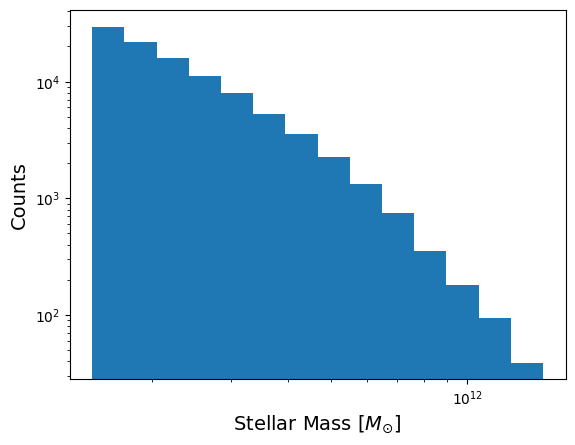

In [22]:
#select column, and get data
#opencosmo automatically gives data with astropy units.
#We use "numpy" to drop the astropy units since we take the log below
mass = ds.select('gal_mass_star').get_data("numpy")

#plot with log bins
bins = np.logspace(np.log10(mass.min()), np.log10(mass.max()), 15)
plt.hist(mass, bins = bins)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Stellar Mass [$M_{\odot}$]', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.show()

> **Note:**
> 
>Our galaxy mass range is limited for the sake of making the following simple plots quick and easy to produce. Due to this limited range, the relations we plot may look slightly off. The reader is encouraged to use more data or better filters to reproduce these plots better on their own!

## Scaling Relations

Let's start by plotting the Tully-Fisher Relation. We will assume a constant mass-to-light ratio ($M/L$) and use stellar mass as a proxy for luminosity. As above, we use `.select()` to get the columns we want data from and plot.

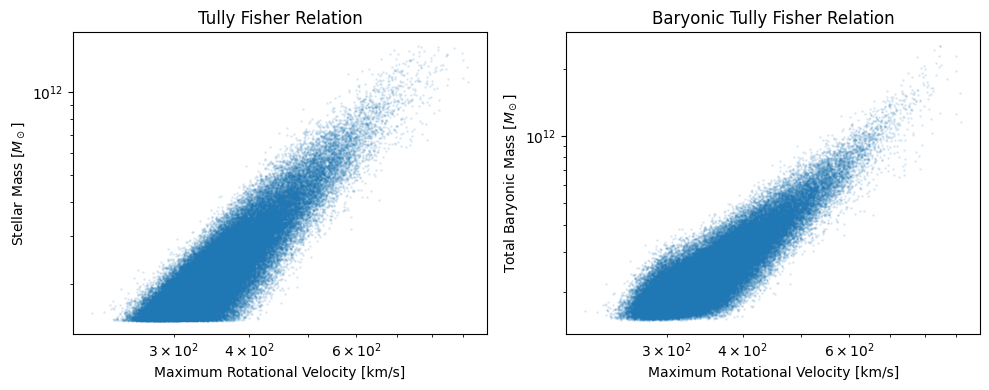

In [23]:
#remember, .get_data() after you select!
Vrot = ds.select('gal_max_cir_vel').get_data() # maximum rotational velocity
Mbar = ds.select('gal_mass_bar').get_data() # baryonic mass

#plot!
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].scatter(Vrot, mass, s=1, alpha = 0.1)
ax[0].set_xlabel('Maximum Rotational Velocity [km/s]')
ax[0].set_ylabel(r'Stellar Mass [$M_\odot$]')
ax[0].set_title('Tully Fisher Relation')
ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].scatter(Vrot, Mbar, s=1, alpha = 0.1)
ax[1].set_xlabel('Maximum Rotational Velocity [km/s]')
ax[1].set_ylabel(r'Total Baryonic Mass [$M_\odot$]')
ax[1].set_title('Baryonic Tully Fisher Relation')
ax[1].set_xscale('log')
ax[1].set_yscale('log')

plt.tight_layout()
plt.show()

Note that the relation isn't perfect since we never explicitly masked out any elliptical galaxies. Let's also plot the Faber-Jackson Relation, since most objects of this mass are ellipticals anyway. The process is the exact same as above, but with different column names:

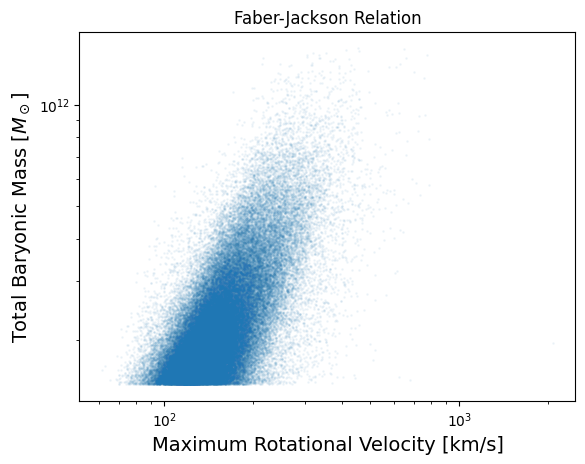

In [24]:
#get velocity dispersion column data
v = ds.select('gal_LOS_stellar_vel_disp').get_data()

#plot
plt.scatter(v, mass, s=1, alpha = 0.05)
plt.xlabel('Maximum Rotational Velocity [km/s]', fontsize=14)
plt.ylabel(r'Total Baryonic Mass [$M_\odot$]', fontsize=14)
plt.title('Faber-Jackson Relation')
plt.xscale('log')
plt.yscale('log')
plt.show()

The simulation our data is from also tracks star formation rate, which we can use to calculate the fraction of our galaxies that are quenched. To do so, we will plot our galaxies in the SFR-$M_*$ parameter space. Below we have also plotted the Star Formation Main Sequence (SFMS, Whitaker et al. 2012) alongside the simulation data and we have placed all immeasureable SFRs to $10^{-2}$.

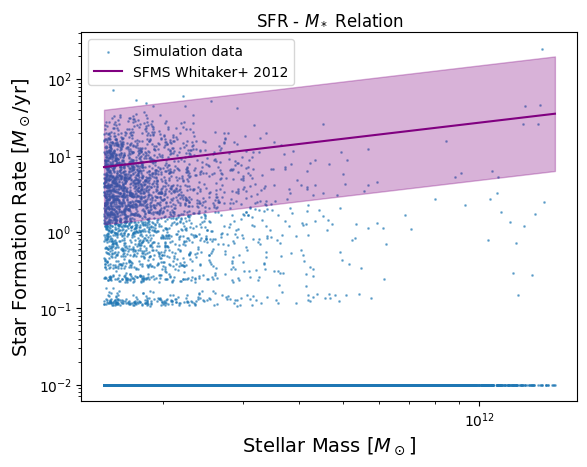

In [25]:
#galaxy SFR, use "numpy" to drop astropy units
sfr = ds.select('gal_sfr').get_data("numpy")

#whitaker et al 2012 line
M_w = np.logspace(np.log10(mass.min()), np.log10(mass.max()))
whit = 10**0.38 * (M_w/10**10.5)**0.7 

#set immeasureable SFR to some arbitrary low value
sfr[sfr == 0.] = 1e-2

#plot
plt.scatter(mass, sfr, s=1, alpha = 0.5, label='Simulation data')
plt.plot(M_w, whit, color = 'purple', label = 'SFMS Whitaker+ 2012')
plt.fill_between(M_w, whit*10**-0.75, whit*10**0.75, color = 'purple', alpha = 0.3)
plt.xlabel(r'Stellar Mass [$M_\odot$]', fontsize=14)
plt.ylabel(r'Star Formation Rate [$M_\odot$/yr]', fontsize=14)
plt.title('SFR - $M_*$ Relation')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

<details>
<summary><b>Question: Do you notice how there seem to be bands and gaps in the data at low SFR? What do you think causes this?</b></summary>

The bands are a result of the simulation resolution. The band around 0.1 SFR are galaxies that only formed 1 star particle. The next band are galaxies that only formed 2 star particles, and so on. We can't get an SFR between these values easily because all the star particles have similar masses and we can't form 1.5 star particles for example.

</details> 

Now we can make one more plot: the quenched fraction as a function of mass. The quenched fraction is the fraction of galaxies that lie below 0.75 dex of the SFMS, represented by the purple shaded region in the above plot. Rather than do the calculation by hand, let's see how we can do it with OpenCosmo!

We will make a new column, called `quench_cutoff`, which will store the value of the SFMS -0.75 dex at the mass of each galaxy. We can quickly make this column by using `.with_new_columns()`. First, we define the cut off, using `.col()` to refer to specific columns in the dataset, and then we feed and the column name into `.with_new_columns()` to have OpenCosmo do the calculation for us and add it as a column to the dataset.

In [26]:
#first, use oc.col() to define the operation we want OpenCosmo to do
cutoff = (10**0.38 * (oc.col('gal_mass_star')/(10**10.5))**0.7) * 10**-0.75

The code cell above didn't calculate anything. We are simply defining a variable that tells OpenCosmo the operation we want it to do. Now we feed that variable into `.with_new_columns()` for OpenCosmo to take care of it for us and add the results as a column.

In [27]:
# This will create a new column called 'quench_cuttoff'.
# the left-hand side of the equality becomes the new column name
data = ds.with_new_columns(quench_cutoff = cutoff)

With this new column, we can calculate the total quenched fraction quickly and easily with some boolean indexing:

In [28]:
# select the relevant columns
sfr = data.select('gal_sfr').get_data("numpy")
qc =  data.select('quench_cutoff').get_data("numpy")

#compute fraction
fq = np.sum([sfr<qc])/len(sfr)

Lastly, we get the quenched fraction as a function of mass by defining and indexing on mass bins as well:

In [29]:
Mbins = np.logspace(np.log10(mass.min()), np.log10(mass.max()), 21) #mass bins
fq_m = np.zeros(len(Mbins)-1) # array for fraction
fq_err = np.zeros(len(Mbins)-1) #array for fraction error (poisson)

#Now we have three criteria, 2 for the mass bin edges, and one to check if the object is quenched
for m in range(len(Mbins) -1):

    #boolean indexing
    for m in range(len(Mbins) -1):
        fq_m[m] = np.sum([(sfr < qc) & (mass > Mbins[m]) & (mass < Mbins[m+1])])/np.sum([(mass > Mbins[m]) & (mass < Mbins[m+1])])
        fq_err[m] = 1/np.sqrt(np.sum([(mass > Mbins[m]) & (mass < Mbins[m+1])])) # Assume a simple poisson error


Now let's plot our handiwork:

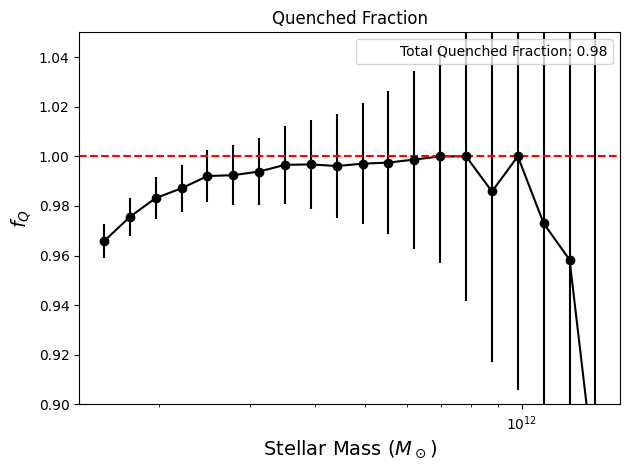

In [30]:
cen =  np.sqrt(Mbins[:-1] * Mbins[1:]) #bin centers
plt.errorbar(cen, fq_m, yerr = fq_err, fmt='o', color = 'k')
plt.plot(cen, fq_m, color = 'k')
plt.plot([],[], ' ', label = f'Total Quenched Fraction: {fq:.2f}')
plt.axhline(y = 1, color = 'r', linestyle = 'dashed')
plt.title(f'Quenched Fraction')
plt.xscale("log")
plt.ylabel(r'$f_Q$', fontsize=14)
plt.xlabel(r'Stellar Mass ($M_\odot$)',fontsize = 14)
plt.ylim(0.9,1.05)
plt.legend()
plt.tight_layout()
plt.show()

These are just a few examples of some plots you can make right out of the box with opencosmo. Many more plots can be made with the values directly calculated in the simulation. Try to make some plots of your own!